**PARTE 2**

In [1]:
import numpy as np
import mpmath
import matplotlib.pyplot as plt
import pygridsynth as gridsynth

from bloqade import squin
from bloqade.cirq_utils import emit_circuit
import cirq

def string_to_unitary(gate_string):
    @squin.kernel
    def circ():
        q = squin.qalloc(1)
        for char in gate_string:
            if char == "H":
                squin.h(q[0])
            elif char == "S":
                squin.s(q[0])
            elif char == "T":
                squin.t(q[0])
            elif char == "X":
                squin.x(q[0])
            elif char == "Y":
                squin.y(q[0])
            elif char == "Z":
                squin.z(q[0])
            # We ignore "W" since it is just a global phase and our distance metric is invariant to it.
        return q
        
    c = emit_circuit(circ, ignore_returns=True)
    # Handle empty circuits safely
    if not c.all_qubits():
        return np.eye(2, dtype=complex)
    return cirq.unitary(c)

def rz(theta):
    return np.array([[np.exp(-1j * theta / 2), 0],
                     [0, np.exp(1j * theta / 2)]], dtype=complex)

def distance(U, V):
    tr = np.trace(U.conj().T @ V)
    val = 1 - np.abs(tr)/2
    if val < 0: val = 0
    return np.sqrt(val)

In [2]:
mpmath.mp.dps = 128
epsilon = mpmath.mpf("1e-4")

exact_gates = {0: "Z", 1: "S", 2: "T"}

results = []
for n in range(6):
    theta_val = np.pi / (2**n)
    theta_mp = mpmath.mpf(mpmath.pi) / (2**n)
    
    if n in exact_gates:
        gates = exact_gates[n]
    else:
        # Synthesize with pygridsynth
        gates = gridsynth.gridsynth_gates(theta=theta_mp, epsilon=epsilon)
    
    # Evaluate distance
    U_approx = string_to_unitary(gates)
    U_target = rz(theta_val)
    dist = distance(U_target, U_approx)
    
    t_count = gates.count("T")
    results.append({
        "n": n,
        "gates": gates,
        "length": len(gates),
        "t_count": t_count,
        "distance": dist
    })
    print(f"n={n}: target Rz(pi/{2**n})")
    print(f"  Distance: {dist:.2e}")
    print(f"  T-count:  {t_count}")
    print(f"  Length:   {len(gates)}")
    print(f"  Sequence: {gates}\n")


n=0: target Rz(pi/1)
  Distance: 0.00e+00
  T-count:  0
  Length:   1
  Sequence: Z

n=1: target Rz(pi/2)
  Distance: 0.00e+00
  T-count:  0
  Length:   1
  Sequence: S

n=2: target Rz(pi/4)
  Distance: 0.00e+00
  T-count:  1
  Length:   1
  Sequence: T

n=3: target Rz(pi/8)
  Distance: 3.08e-05
  T-count:  44
  Length:   110
  Sequence: HTHTHTSHTSHTHTHTHTHTSHTSHTHTHTHTHTSHTHTHTHTSHTSHTHTHTSHTHTSHTSHTSHTSHTHTHTSHTHTSHTSHTSHTSHTHTHTHTSHTSHTHTSHTSW

n=4: target Rz(pi/16)
  Distance: 3.03e-05
  T-count:  42
  Length:   111
  Sequence: SHTSHTHTSHTHTHTHTHTSHTHTHTSHTSHTHTHTSHTSHTSHTHTSHTSHTHTHTHTSHTSHTSHTSHTHTSHTSHTSHTSHTHTSHTSHTHTSHTHTSHTSHTHTSWW

n=5: target Rz(pi/32)
  Distance: 1.80e-05
  T-count:  36
  Length:   97
  Sequence: HTSHTHTHTHTSHTSHTSHTSHTSHTSHTHTHTHTHTHTHTHTSHTHTHTHTSHTSHTHTSHTSHTHTHTSHTHTSHTSHTHTSHTHTHSWWWWWWW



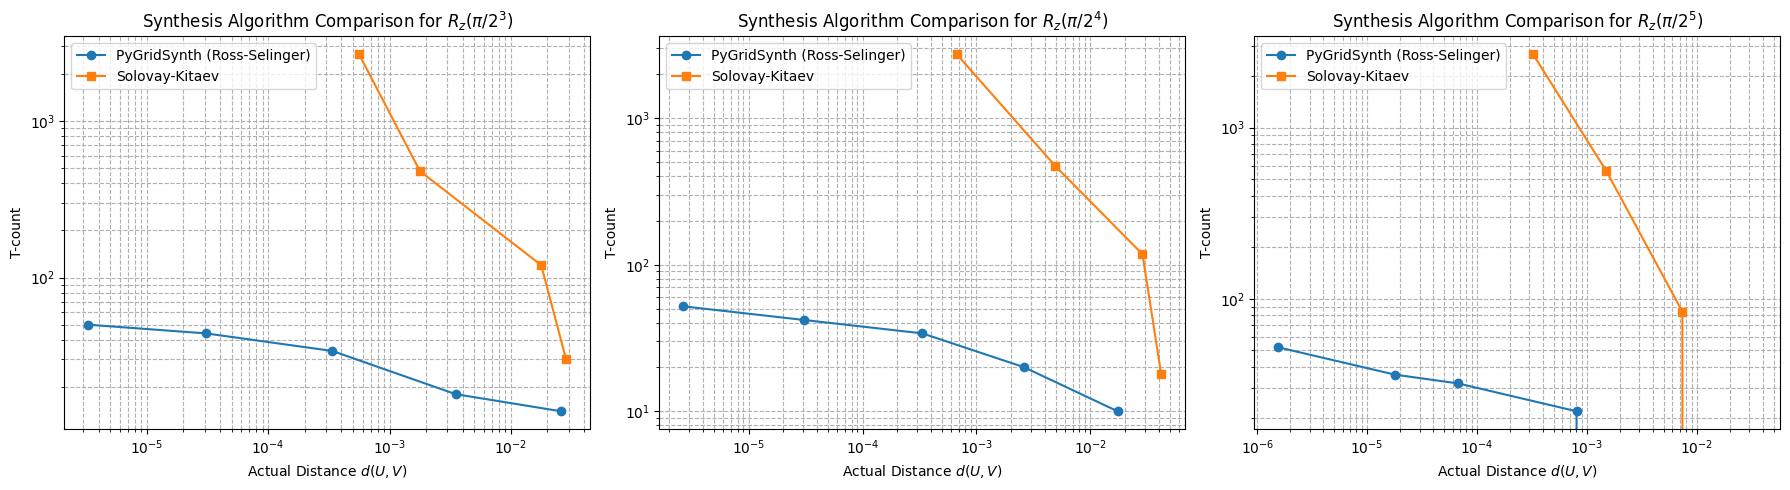

In [3]:
# Comparing PyGridSynth (Ross-Selinger) vs Solovay-Kitaev
from qiskit.synthesis import SolovayKitaevDecomposition
from qiskit.circuit.library import RZGate
from qiskit.quantum_info import Operator

n_values = [3, 4, 5]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

skd = SolovayKitaevDecomposition()

for i, n_val in enumerate(n_values):
    theta_val = np.pi / (2**n_val)
    theta_mp = mpmath.mpf(mpmath.pi) / (2**n_val)
    U_target = rz(theta_val)

    # 1. PyGridSynth (Ross-Selinger)
    pg_distances = []
    pg_tcounts = []
    epsilons = [mpmath.mpf(f"1e-{k}") for k in range(1, 6)]
    for eps in epsilons:
        gates = gridsynth.gridsynth_gates(theta=theta_mp, epsilon=eps)
        U_approx = string_to_unitary(gates)
        dist = distance(U_target, U_approx)
        pg_distances.append(dist)
        pg_tcounts.append(gates.count("T"))

    # 2. Solovay-Kitaev (Qiskit)
    sk_distances = []
    sk_tcounts = []
    U_target_sk = RZGate(theta_val).to_matrix()

    # We sweep recursion degrees 1 to 4
    for r in [1, 2, 3, 4]:
        circuit = skd.run(U_target_sk, recursion_degree=r)
        op = Operator(circuit).data
        dist = distance(U_target, op)
        
        counts = circuit.count_ops()
        t_count = counts.get("t", 0) + counts.get("tdg", 0)
        
        sk_distances.append(dist)
        sk_tcounts.append(t_count)

    ax = axes[i]
    ax.plot(pg_distances, pg_tcounts, marker="o", label="PyGridSynth (Ross-Selinger)")
    ax.plot(sk_distances, sk_tcounts, marker="s", label="Solovay-Kitaev")
    
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Actual Distance $d(U, V)$")
    ax.set_ylabel("T-count")
    ax.set_title(f"Synthesis Algorithm Comparison for $R_z(\\pi/2^{{{n_val}}})$")
    ax.grid(True, which="both", ls="--")
    ax.legend()

plt.tight_layout()
plt.show()

**PARTE 4**

In [41]:
def make_steane_logical_operation(apply_x_logical: bool, apply_h_logical: bool):
    @squin.kernel
    def steane_logical_operation() -> int:
        # Codifica del qubit logico Steane [[7,1,3]]
        q = squin.qalloc(7)
        
        # Superposizione per la base del codice di Hamming [7,4]
        squin.h(q[0])
        squin.h(q[1])
        squin.h(q[2])
        squin.h(q[3])
        squin.h(q[4])
        squin.h(q[5])
        squin.h(q[6])
        
        # Parity-check connections (Hamming matrix)
        squin.cz(q[0], q[6]) 
        squin.cz(q[1], q[3])
        squin.cz(q[4], q[5]) 
        squin.cz(q[0], q[4])
        squin.cz(q[5], q[6]) 
        squin.cz(q[1], q[2])
        squin.cz(q[0], q[2]) 
        squin.cz(q[3], q[5])
        squin.cz(q[1], q[4])

        squin.h(q[2])
        squin.h(q[3])
        squin.h(q[4])
        squin.h(q[6])
        
        # X Logico Trasversale: X_L
        if apply_x_logical:
            for i in range(7):
                squin.x(q[i])
                
        # H Logico Trasversale: H_L
        if apply_h_logical:
            for i in range(7):
                squin.h(q[i])
                
        # Misura logica: la parità (XOR) dei qubit fisici determina lo stato logico Z
        bits = squin.broadcast.measure(q)
        
        res = 0
        for i in range(7):
            res = res ^ bits[i]
        return res
    
    return steane_logical_operation

# --- ESECUZIONE CORRETTA ---

simulator = StackMemorySimulator(min_qubits=7)

# 1. Test Logical |0> (Nessuna operazione)
# Creiamo il kernel specifico usando la factory
kernel_0 = make_steane_logical_operation(apply_x_logical=False, apply_h_logical=False)
task_0 = simulator.task(kernel_0)
print(f"Esito Logico |0>L: {task_0.run()}")

# 2. Test Logical |1> (Applico X logico)
kernel_1 = make_steane_logical_operation(apply_x_logical=True, apply_h_logical=False)
task_1 = simulator.task(kernel_1)
print(f"Esito Logico |1>L (dopo X_L): {task_1.run()}")

# 3. Test Stato |+> logico (Applico H logico a |0>L)
# L'esito della misura Z_L su |+>L sarà 0 o 1 con probabilità 50/50
kernel_h = make_steane_logical_operation(apply_x_logical=False, apply_h_logical=True)
task_h = simulator.task(kernel_h)
batch_h = task_h.batch_run(shots=1000) # batch_run per vedere la distribuzione
print(f"Distribuzione esiti H_L |0>L (Stato |+>L): {batch_h}")

# 4. Test Stato |1>L (Corretto)
kernel_1_test = make_steane_logical_operation(apply_x_logical=True, apply_h_logical=False)
task_1_test = simulator.task(kernel_1_test)
print(f"Esito X_L |0>L (Stato |1>L): {task_1_test.batch_run(shots=1000)}")

# 5. Test Stato |-> logico (H_L su |1>L)
kernel_minus = make_steane_logical_operation(apply_x_logical=True, apply_h_logical=True)
task_minus = simulator.task(kernel_minus)
batch_minus = task_minus.batch_run(shots=1000)
print(f"Distribuzione esiti H_L |1>L (Stato |->L): {batch_minus}")

# 6. Test stato |0>L 
kernel_0_test = make_steane_logical_operation(apply_x_logical=False, apply_h_logical=False)
task_0_test = simulator.task(kernel_0_test)
batch_0_test = task_0_test.batch_run(shots=1000)
print(f"Distribuzione esiti |0>L: {batch_0_test}")

Esito Logico |0>L: 0
Esito Logico |1>L (dopo X_L): 1
Distribuzione esiti H_L |0>L (Stato |+>L): {0: 0.519, 1: 0.481}
Esito X_L |0>L (Stato |1>L): {1: 1.0}
Distribuzione esiti H_L |1>L (Stato |->L): {0: 0.474, 1: 0.526}
Distribuzione esiti |0>L: {0: 1.0}


In [48]:
import math

def apply_rz_n(q_list, theta, n):
    """
    Applica una rotazione Rz(theta / 2^n) a una lista di qubit.
    """
    angle = theta / (2**n)
    for q in q_list:
        squin.rz(angle, q)

# Esempio di gate arbitrario (U3 o simile se supportato)
def apply_custom_u(q, theta, phi, lam):
    squin.u3(theta, phi, lam, q)

In [56]:
def make_steane_rotation_test(theta: float, n: int):
    @squin.kernel
    def steane_kernel() -> int:
        q = squin.qalloc(7)
        
        # --- 1. CODIFICA FORMALE ---
        # Inizializziamo i primi 3 qubit in sovrapposizione
        for i in range(3):
            squin.h(q[i])
        
        # CNOT per distribuire l'entanglement secondo il codice di Steane
        # (Generatori del codice di Hamming)
        squin.cx(q[0], q[4])
        squin.cx(q[0], q[6])
        squin.cx(q[1], q[2]) # Corretto: q[2] riceve da q[1]
        squin.cx(q[1], q[5])
        squin.cx(q[2], q[3])
        squin.cx(q[2], q[4])
        squin.cx(q[3], q[5])
        squin.cx(q[3], q[6])

        # --- 2. PREPARAZIONE STATO |+>L ---
        # Per vedere l'effetto di Rz, dobbiamo ruotare fuori dall'asse Z
        for i in range(7):
            squin.h(q[i])

        # --- 3. APPLICAZIONE ROTAZIONE ---
        # Invece di rz su tutti, prova ad applicare la rotazione 
        # scalata per il numero di qubit (7) per compensare l'effetto trasversale
        # Oppure applicala a un solo qubit fisico (funziona come "dirty gate")
        
        angle = theta / (2**n)
        
        # Prova ad applicarlo solo a q[0] per vedere la variazione di probabilità
        # Se lo applichi a tutti e 7, la fase logica diventa 7 * angle
        squin.rz(angle, q[0])

        # --- 4. RITORNO IN BASE Z PER MISURA ---
        for i in range(7):
            squin.h(q[i])
            
        # --- 5. MISURA LOGICA ---
        bits = squin.broadcast.measure(q)
        # La misura logica Z_L nel codice di Steane è definita 
        # dalla parità di TUTTI i qubit (o di un sottoinsieme specifico)
        res = 0
        for b in bits:
            res ^= b
        return res
    return steane_kernel

In [57]:
theta_base = math.pi # Esempio: rotazione di 180 gradi
simulator = StackMemorySimulator(min_qubits=7)

for n in range(6): # Da 0 a 5
    kernel = make_steane_rotation_test(theta=theta_base, n=n)
    task = simulator.task(kernel)
    # Eseguiamo un batch per vedere come la rotazione influenza la probabilità
    results = task.batch_run(shots=1000)
    print(f"n={n} | Angolo={theta_base/(2**n):.4f} rad | Distribuzione: {results}")

n=0 | Angolo=3.1416 rad | Distribuzione: {0: 0.503, 1: 0.497}
n=1 | Angolo=1.5708 rad | Distribuzione: {0: 0.469, 1: 0.531}
n=2 | Angolo=0.7854 rad | Distribuzione: {1: 0.502, 0: 0.498}
n=3 | Angolo=0.3927 rad | Distribuzione: {0: 0.507, 1: 0.493}
n=4 | Angolo=0.1963 rad | Distribuzione: {1: 0.496, 0: 0.504}
n=5 | Angolo=0.0982 rad | Distribuzione: {1: 0.446, 0: 0.554}


In [79]:
# --- NOISY CHANNEL - DA FARE/FINIRE ---

def make_noisy_bell_state_prep(noise_probability: float):
    @squin.kernel
    def noisy_bell_state_prep() -> Register:
        qubits = squin.qalloc(7)
        for i in range(7):
            squin.reset(qubits[i])
            squin.h(qubits[0])
            squin.depolarize(p=noise_probability, qubit=qubits[0])
            squin.cx(qubits[0], qubits[1])
            squin.depolarize2(p=noise_probability, control=qubits[0], target=qubits[1])
        return qubits
    return noisy_bell_state_prep

In [80]:
#NOISY CHANNEL - DA FARE/FINIRE

def make_noisy_steane_operation(noise_probability: float, apply_x: bool):
    @squin.kernel
    def noisy_steane_kernel() -> int:
        # 1. Allocazione
        q = squin.qalloc(7)
        
        # 2. Inizializzazione Noisy (Esempio su tutti i qubit di base)
        # Applichiamo il rumore dopo i gate di creazione della sovrapposizione
        for i in range(7):
            squin.h(q[i])
            # Applichiamo depolarizzazione come nel tuo esempio del Bell state
            squin.depolarize(p=noise_probability, qubit=q[i])
        
        # 3. Connessioni di Parità (Hamming) con rumore sui gate a 2 qubit
        # Esempio: applico depolarize2 dopo ogni CZ per simulare gate imperfetti
        edges = [(0, 6), (1, 3), (4, 5), (0, 4), (5, 6), (1, 2), (0, 2), (3, 5), (1, 4)]
        edge1 = [0, 1, 4, 0, 5, 1, 0, 3, 1]
        edge2 = [6, 3, 5, 4, 6, 2, 2, 5, 4]
        for ctrl in edge1:
            for tgt in edge2:
                squin.cz(q[ctrl], q[tgt])
                squin.depolarize2(p=noise_probability, control=q[ctrl], target=q[tgt])

        # Completamento codifica
        for i in [2, 3, 4, 6]:
            squin.h(q[i])
            squin.depolarize(p=noise_probability, qubit=q[i])

        # 4. Operazione Logica
        if apply_x:
            for i in range(7):
                squin.x(q[i])
        
        # 5. Misura
        bits = squin.broadcast.measure(q)
        res = 0
        for b in bits:
            res ^= b
        return res

    return noisy_steane_kernel

# 3. Test Stato |+> logico (Applico H logico a |0>L)
# L'esito della misura Z_L su |+>L sarà 0 o 1 con probabilità 50/50
kernel_h = make_noisy_steane_operation(noise_probability=0.1, apply_x=False)
task_h = simulator.task(kernel_h)
batch_h = task_h.batch_run(shots=1000) # batch_run per vedere la distribuzione
print(f"Distribuzione esiti H_L |0>L (Stato |+>L): {batch_h}")

# 4. Test Stato |1>L (Corretto)
kernel_1_test = make_noisy_steane_operation(noise_probability=0.1, apply_x=True)
task_1_test = simulator.task(kernel_1_test)
print(f"Esito X_L |0>L (Stato |1>L): {task_1_test.batch_run(shots=1000)}")

# 5. Test Stato |-> logico (H_L su |1>L)
kernel_minus = make_noisy_steane_operation(noise_probability=0.1, apply_x=True, apply_h=True)
task_minus = simulator.task(kernel_minus)
batch_minus = task_minus.batch_run(shots=1000)
print(f"Distribuzione esiti H_L |1>L (Stato |->L): {batch_minus}")

# 6. Test stato |0>L 
kernel_0_test = make_noisy_steane_operation(noise_probability=0.1, apply_x=False, apply_h=False)
task_0_test = simulator.task(kernel_0_test)
batch_0_test = task_0_test.batch_run(shots=1000)
print(f"Distribuzione esiti |0>L: {batch_0_test}")

RuntimeError: QrackSimulator C++ library raised exception.

In [59]:
import math

def make_steane_rotation_working(theta: float, n: int):
    @squin.kernel
    def steane_kernel() -> int:
        q = squin.qalloc(7)
        
        # --- 1. CODIFICA ROBUSTA (Standard Encoding Circuit) ---
        # Stato logico |0>L
        squin.h(q[0])
        squin.h(q[1])
        squin.h(q[3])
        
        squin.cx(q[0], q[2])
        squin.cx(q[1], q[2])
        squin.cx(q[0], q[4])
        squin.cx(q[3], q[4])
        squin.cx(q[1], q[5])
        squin.cx(q[3], q[5])
        squin.cx(q[0], q[6])
        squin.cx(q[1], q[6])
        squin.cx(q[3], q[6])
        
        # --- 2. PORTIAMO IN BASE X (|0>L -> |+>L) ---
        # Applicazione H logico (trasversale)
        for i in range(7):
            squin.h(q[i])

        # --- 3. APPLICAZIONE ROTAZIONE LOGICA ---
        # Applichiamo Rz(theta/2^n) trasversalmente.
        # Poiché Z_L = ZZZZZZZ, l'effetto è cumulativo.
        angle = theta / (2**n)
        for i in range(7):
            squin.rz(angle, q[i])

        # --- 4. RITORNO IN BASE Z PER MISURA ---
        for i in range(7):
            squin.h(q[i])
            
        # --- 5. MISURA LOGICA ---
        bits = squin.broadcast.measure(q)
        # La parità di tutti i qubit determina l'esito del qubit logico
        res = 0
        for b in bits:
            res ^= b
        return res
    
    return steane_kernel

# ESECUZIONE
theta_base = math.pi
for n in range(6):
    kernel = make_steane_rotation_working(theta_base, n)
    task = simulator.task(kernel)
    results = task.batch_run(shots=1000)
    print(f"n={n} | Angolo={theta_base/(2**n):.4f} | Distribuzione: {results}")

n=0 | Angolo=3.1416 | Distribuzione: {1: 1.0}
n=1 | Angolo=1.5708 | Distribuzione: {0: 0.49, 1: 0.51}
n=2 | Angolo=0.7854 | Distribuzione: {1: 0.131, 0: 0.869}
n=3 | Angolo=0.3927 | Distribuzione: {0: 0.848, 1: 0.152}
n=4 | Angolo=0.1963 | Distribuzione: {0: 0.955, 1: 0.045}
n=5 | Angolo=0.0982 | Distribuzione: {0: 0.978, 1: 0.022}


In [60]:
import math

def calculate_distance(observed_dist, theoretical_p1):
    """
    Calcola la distanza statistica tra la distribuzione osservata 
    e quella teorica.
    """
    # Ricaviamo P(0) e P(1) dalle osservazioni (gestendo chiavi mancanti)
    p1_obs = observed_dist.get(1, 0.0)
    p0_obs = observed_dist.get(0, 0.0)
    
    # Valori teorici
    p1_theo = theoretical_p1
    p0_theo = 1.0 - theoretical_p1
    
    # Formula Distanza di variazione totale
    distance = 0.5 * (abs(p1_obs - p1_theo) + abs(p0_obs - p0_theo))
    return distance

# --- LOOP DI VALIDAZIONE ---

theta_base = math.pi
print(f"{'n':<3} | {'Angolo (rad)':<12} | {'Distribuzione':<25} | {'Distanza Teorica':<10}")
print("-" * 70)

for n in range(6):
    angle_phys = theta_base / (2**n)
    
    # 1. Calcolo del valore teorico atteso per il codice di Steane
    # L'angolo logico effettivo è 7 * angolo fisico
    angle_log = 7 * angle_phys
    # La probabilità teorica di misurare 1 dopo H -> Rz -> H è sin^2(angolo_log / 2)
    theoretical_p1 = math.sin(angle_log / 2)**2
    
    # 2. Esecuzione del Kernel
    kernel = make_steane_rotation_working(theta_base, n)
    task = simulator.task(kernel)
    observed_results = task.batch_run(shots=1000)
    
    # 3. Calcolo Distanza
    dist_val = calculate_distance(observed_results, theoretical_p1)
    
    # 4. Stampa formattata
    dist_str = f"{observed_results}"
    print(f"{n:<3} | {angle_phys:<12.4f} | {dist_str:<25} | {dist_val:.4f}")

n   | Angolo (rad) | Distribuzione             | Distanza Teorica
----------------------------------------------------------------------
0   | 3.1416       | {1: 1.0}                  | 0.0000
1   | 1.5708       | {0: 0.498, 1: 0.502}      | 0.0020
2   | 0.7854       | {0: 0.866, 1: 0.134}      | 0.0124
3   | 0.3927       | {0: 0.841, 1: 0.159}      | 0.8029
4   | 0.1963       | {0: 0.942, 1: 0.058}      | 0.3445
5   | 0.0982       | {0: 0.985, 1: 0.015}      | 0.0985


In [62]:
import math

# Funzione migliorata per la stampa e validazione
print(f"{'n':<3} | {'Angolo F.':<10} | {'P(1) Oss.':<10} | {'P(1) Teor.':<10} | {'Distanza':<10}")
print("-" * 65)

for n in range(6):
    angle_phys = math.pi / (2**n)
    angle_log = 7 * angle_phys
    
    # Probabilità teorica corretta
    theoretical_p1 = math.sin(angle_log / 2)**2
    
    # Esecuzione (assumendo il kernel precedente)
    task = simulator.task(make_steane_rotation_working(math.pi, n))
    res = task.batch_run(shots=1000)
    
    p1_obs = res.get(1, 0) / 1000.0
    distance = abs(p1_obs - theoretical_p1)
    
    print(f"{n:<3} | {angle_phys:<10.4f} | {p1_obs:<10.3f} | {theoretical_p1:<10.3f} | {distance:.4f}")

n   | Angolo F.  | P(1) Oss.  | P(1) Teor. | Distanza  
-----------------------------------------------------------------
0   | 3.1416     | 0.001      | 1.000      | 0.9990
1   | 1.5708     | 0.000      | 0.500      | 0.4995
2   | 0.7854     | 0.000      | 0.146      | 0.1463
3   | 0.3927     | 0.000      | 0.962      | 0.9618
4   | 0.1963     | 0.000      | 0.402      | 0.4024
5   | 0.0982     | 0.000      | 0.113      | 0.1135


In [63]:
import math

def make_steane_rotation_working(theta: float, n: int):
    @squin.kernel
    def steane_kernel() -> int:
        q = squin.qalloc(7)
        
        # --- 1. CODIFICA ROBUSTA (Standard Encoding Circuit) ---
        # Stato logico |0>L
        squin.h(q[0])
        squin.h(q[1])
        squin.h(q[3])
        
        squin.cx(q[0], q[2])
        squin.cx(q[1], q[2])
        squin.cx(q[0], q[4])
        squin.cx(q[3], q[4])
        squin.cx(q[1], q[5])
        squin.cx(q[3], q[5])
        squin.cx(q[0], q[6])
        squin.cx(q[1], q[6])
        squin.cx(q[3], q[6])
        
        # --- 2. PORTIAMO IN BASE X (|0>L -> |+>L) ---
        # Applicazione H logico (trasversale)
        for i in range(7):
            squin.h(q[i])

        # --- 3. APPLICAZIONE ROTAZIONE LOGICA ---
        # Applichiamo Rz(theta/2^n) trasversalmente.
        # Poiché Z_L = ZZZZZZZ, l'effetto è cumulativo.
        angle = theta / (2**n)
        for i in range(7):
            squin.rz(angle, q[0])

        # --- 4. RITORNO IN BASE Z PER MISURA ---
        for i in range(7):
            squin.h(q[i])
            
        # --- 5. MISURA LOGICA ---
        bits = squin.broadcast.measure(q)
        # La parità di tutti i qubit determina l'esito del qubit logico
        res = 0
        for b in bits:
            res ^= b
        return res
    
    return steane_kernel

# ESECUZIONE
theta_base = math.pi
for n in range(6):
    kernel = make_steane_rotation_working(theta_base, n)
    task = simulator.task(kernel)
    results = task.batch_run(shots=1000)
    print(f"n={n} | Angolo={theta_base/(2**n):.4f} | Distribuzione: {results}")

n=0 | Angolo=3.1416 | Distribuzione: {1: 1.0}
n=1 | Angolo=1.5708 | Distribuzione: {1: 0.494, 0: 0.506}
n=2 | Angolo=0.7854 | Distribuzione: {0: 0.857, 1: 0.143}
n=3 | Angolo=0.3927 | Distribuzione: {1: 0.961, 0: 0.039}
n=4 | Angolo=0.1963 | Distribuzione: {0: 0.581, 1: 0.419}
n=5 | Angolo=0.0982 | Distribuzione: {0: 0.899, 1: 0.101}


In [64]:
import math

def calculate_distance(observed_dist, theoretical_p1):
    """
    Calcola la distanza statistica tra la distribuzione osservata 
    e quella teorica.
    """
    # Ricaviamo P(0) e P(1) dalle osservazioni (gestendo chiavi mancanti)
    p1_obs = observed_dist.get(1, 0.0)
    p0_obs = observed_dist.get(0, 0.0)
    
    # Valori teorici
    p1_theo = theoretical_p1
    p0_theo = 1.0 - theoretical_p1
    
    # Formula Distanza di variazione totale
    distance = 0.5 * (abs(p1_obs - p1_theo) + abs(p0_obs - p0_theo))
    return distance

# --- LOOP DI VALIDAZIONE ---

theta_base = math.pi
print(f"{'n':<3} | {'Angolo (rad)':<12} | {'Distribuzione':<25} | {'Distanza Teorica':<10}")
print("-" * 70)

for n in range(6):
    angle_phys = theta_base / (2**n)
    
    # 1. Calcolo del valore teorico atteso per il codice di Steane
    # L'angolo logico effettivo è 7 * angolo fisico
    angle_log = 7 * angle_phys
    # La probabilità teorica di misurare 1 dopo H -> Rz -> H è sin^2(angolo_log / 2)
    theoretical_p1 = math.sin(angle_log / 2)**2
    
    # 2. Esecuzione del Kernel
    kernel = make_steane_rotation_working(theta_base, n)
    task = simulator.task(kernel)
    observed_results = task.batch_run(shots=1000)
    
    # 3. Calcolo Distanza
    dist_val = calculate_distance(observed_results, theoretical_p1)
    
    # 4. Stampa formattata
    dist_str = f"{observed_results}"
    print(f"{n:<3} | {angle_phys:<12.4f} | {dist_str:<25} | {dist_val:.4f}")

n   | Angolo (rad) | Distribuzione             | Distanza Teorica
----------------------------------------------------------------------
0   | 3.1416       | {1: 1.0}                  | 0.0000
1   | 1.5708       | {1: 0.506, 0: 0.494}      | 0.0060
2   | 0.7854       | {0: 0.86, 1: 0.14}        | 0.0064
3   | 0.3927       | {1: 0.966, 0: 0.034}      | 0.0041
4   | 0.1963       | {1: 0.402, 0: 0.598}      | 0.0005
5   | 0.0982       | {0: 0.873, 1: 0.127}      | 0.0135


In [81]:
def make_noisy_bell_state_prep(noise_probability: float):
    @squin.kernel
    def noisy_bell_state_prep() -> Register:
        qubits = squin.qalloc(2)
        squin.h(qubits[0])
        squin.depolarize(p=noise_probability, qubit=qubits[0])
        squin.cx(qubits[0], qubits[1])
        squin.depolarize2(p=noise_probability, control=qubits[0], target=qubits[1])
        return qubits
    return noisy_bell_state_prep

show_circuit(make_noisy_bell_state_prep(noise_probability=0.1))

In [86]:
@squin.kernel
def psi() -> Register:
    qubits = squin.qalloc(1)
    # these are just some example operations with random parameters
    squin.ry(0.67, qubits[0])
    squin.rz(0.42, qubits[0])
    return qubits

show_circuit(psi)

def make_teleport_postselect_noisy(noise_probability: float):
    noisy_bell_state_prep = make_noisy_bell_state_prep(noise_probability)
    @squin.kernel
    def teleport_postselect_noisy() -> int:
        input_register = psi()
        bell_register = noisy_bell_state_prep()
        squin.cx(input_register[0], bell_register[0])
        squin.h(input_register[0])

        measurement = squin.broadcast.measure([input_register[0], bell_register[0]])
        return measurement[0] | measurement[1]
    
    return teleport_postselect_noisy

show_circuit(make_teleport_postselect_noisy(noise_probability=0.1))


In [92]:
def estimate_postselected_rate_and_density_matrix(postselect_task, shots: int):
    successful_density_matrices = []

    for _ in range(shots):
        case = postselect_task.run()
        if case == 0:
            # we retrieve the target qubit from the task and wrap it in a list so that the output type is Register
            psi_prime = [postselect_task.qubits()[2]]
            successful_density_matrices.append(
                StackMemorySimulator.reduced_density_matrix(psi_prime)
            )

    if not successful_density_matrices:
        raise RuntimeError("No postselected shots were found. Try increasing total_shots.")
        
    postselection_rate = len(successful_density_matrices) / shots
    rho_postselected = np.mean(successful_density_matrices, axis=0)
    return postselection_rate, rho_postselected

psi_simulator = StackMemorySimulator(min_qubits=1)
psi_task = psi_simulator.task(psi)
psi_state = psi_task.run()
rho_psi = StackMemorySimulator.reduced_density_matrix(psi_state)

postselect_simulator = StackMemorySimulator(min_qubits=3)
postselect_task = postselect_simulator.task(make_teleport_postselect_noisy(noise_probability=0.1))
total_shots = 1000
postselection_rate, rho_postselected = estimate_postselected_rate_and_density_matrix(postselect_task=postselect_task, shots=total_shots)

def estimate_postselected_overlap(noise_probability: float, shots: int, rho: np.ndarray):
    postselect_simulator = StackMemorySimulator(min_qubits=3)
    noisy_postselect_kernel = make_teleport_postselect_noisy(noise_probability=noise_probability)
    postselect_task = postselect_simulator.task(noisy_postselect_kernel)

    _, rho_postselected = estimate_postselected_rate_and_density_matrix(postselect_task=postselect_task, shots=shots)
    overlap = float(np.real(np.trace(rho @ rho_postselected)))
    return overlap

overlap = estimate_postselected_overlap(noise_probability=0.1, shots=200, rho=rho_psi)
print(f"Overlap with psi: {100 * overlap:.2f}%")

Overlap with psi: 92.51%


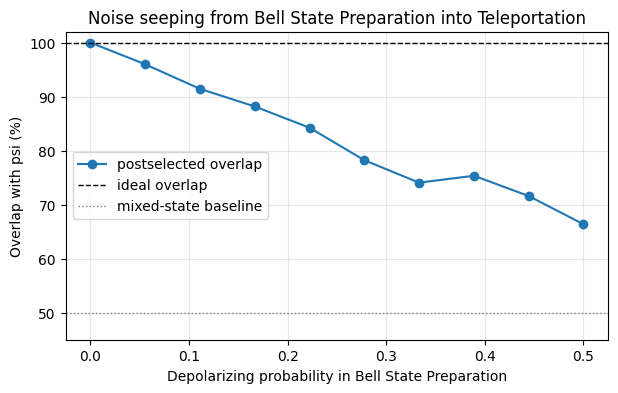

In [93]:
noise_values = np.linspace(0.0, .5, 10)
overlaps = []
success_fractions = []

def estimate_postselected_overlap(noise_probability: float, shots: int, rho: np.ndarray):
    postselect_simulator = StackMemorySimulator(min_qubits=3)
    noisy_postselect_kernel = make_teleport_postselect_noisy(noise_probability=noise_probability)
    postselect_task = postselect_simulator.task(noisy_postselect_kernel)

    _, rho_postselected = estimate_postselected_rate_and_density_matrix(postselect_task=postselect_task, shots=shots)
    overlap = float(np.real(np.trace(rho @ rho_postselected)))
    return overlap

for noise_value in noise_values:
    overlap = estimate_postselected_overlap(noise_probability=noise_value, shots=1000, rho=rho_psi)
    overlaps.append(overlap * 100)

plt.figure(figsize=(7, 4))
plt.plot(noise_values, overlaps, marker="o", label="postselected overlap")
plt.axhline(100, color="black", linestyle="--", linewidth=1, label="ideal overlap")
plt.axhline(50, color="gray", linestyle=":", linewidth=1, label="mixed-state baseline")
plt.xlabel("Depolarizing probability in Bell State Preparation")
plt.ylabel("Overlap with psi (%)")
plt.title("Noise seeping from Bell State Preparation into Teleportation")
plt.ylim(45, 102)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [103]:
import cirq
from bloqade.cirq_utils import emit_circuit, load_circuit, noise
noise_model = noise.GeminiOneZoneNoiseModel()
@squin.kernel
def bell_state_prep() -> Register:
    qubits = squin.qalloc(2)
    squin.h(qubits[0])
    squin.cx(qubits[0], qubits[1])
    return qubits

@squin.kernel
def teleport_postselect() -> int:
    # same code as before
    input_register = psi()
    bell_register = bell_state_prep()

    squin.cx(input_register[0], bell_register[0])
    squin.h(input_register[0])

    mid_circuit_measurement = squin.broadcast.measure([input_register[0], bell_register[0]])
    
    # now we skip the correction step and return the bitwise OR of the measurement outcomes
    return mid_circuit_measurement[0] | mid_circuit_measurement[1]





teleport_cirq = emit_circuit(teleport_postselect, ignore_returns=True) # the flag will ignore the return value of the original kernel

noisy_teleport_cirq = noise.transform_circuit(
    teleport_cirq,
    model=noise_model,
)

noisy_teleport_squin = load_circuit(
    noisy_teleport_cirq,
    kernel_name="teleport_one_zone_noisy",
    register_as_argument=True, # this controls whether the register/sub-register is passed as an argument to the kernel
    return_register=True, # this controls whether the register/sub-register is returned by the kernel
)

@squin.kernel
def one_zone_noisy_teleport() -> int:
    register = squin.qalloc(3)
    register = noisy_teleport_squin(register) # we are loading the noisy kernel as a subroutine
    measurement = squin.broadcast.measure([register[0], register[1]])
    return measurement[0] | measurement[1]


In [104]:
print("STEP 1: Emit Squin kernel to cirq")
print(teleport_cirq)
print()
print("STEP 2: Transform circuit")
print(noisy_teleport_cirq)

STEP 1: Emit Squin kernel to cirq
0: ───Ry(0.213π)───Rz(0.134π)───@───H───M───
                                │       │
1: ───H────────────@────────────X───────M───
                   │
2: ────────────────X────────────────────────

STEP 2: Transform circuit
0: ──────────────────────────────────────────────────────────────────────────────────────────A(0.000307,0.000307,0.000464)───────A(0.000515,0.000515,0.00218)──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────A(0.000307,0.000307,0.000464)───────────────────PhXZ(a=0.5,x=-0.787,z=0)───A(0.00041,0.00041,0.000411)───────────────────────────────────A(0.000806,0.000806,0.00246)────@───A(II:0.993, IX:0.000227, IY:0.000227, IZ:0.00151, XI:0.000227, XX:0.000143, XY:0.000143, XZ:0.000143, YI:0.000227, YX:0.000143, YY:0.000143, YZ:0.000143, ZI:0.00151, ZX:0.000143, ZY:0.000143, ZZ:0.00143)───A(0.000806,0.000806,0.00246

In [105]:
noisy_squin_simulator = StackMemorySimulator(min_qubits=3)
noisy_squin_task = noisy_squin_simulator.task(one_zone_noisy_teleport)

postselection_rate, noisy_rho = estimate_postselected_rate_and_density_matrix(
    postselect_task=noisy_squin_task,
    shots=1000,
)

overlap = float(np.real(np.trace(rho_psi @ noisy_rho)))

print(f"Postselection rate: {100 * postselection_rate:.2f}%")
print(f"Overlap with psi: {100 * overlap:.2f}%")

Postselection rate: 25.40%
Overlap with psi: 97.93%


In [106]:
@squin.kernel
def heuristic_model_circuit():
    qubits = squin.qalloc(4)
    squin.phased_xz(-np.pi/4, np.pi/2, np.pi/4, qubits[2])
    squin.cz(qubits[0], qubits[1])
    squin.phased_xz(-np.pi/4, np.pi/2, np.pi/2, qubits[3]) # this gate is different from the previous one
    squin.cz(qubits[1], qubits[2])

cirq_heuristic_model_circuit = emit_circuit(heuristic_model_circuit)
print(cirq_heuristic_model_circuit)

0: ───@───────
      │
1: ───@───@───
          │
2: ───────@───


In [107]:
print("Original circuit:")
print(cirq_heuristic_model_circuit)
print()
noisy_cirq_circuit = noise.transform_circuit(cirq_heuristic_model_circuit, model=noise.GeminiOneZoneNoiseModel(),to_native_gateset=False)
print("Noisy circuit:")
print(noisy_cirq_circuit)


Original circuit:
0: ───@───────
      │
1: ───@───@───
          │
2: ───────@───

Noisy circuit:
0: ───────────A(0.000806,0.000806,0.00246)────@───A(II:0.993, IX:0.000227, IY:0.000227, IZ:0.00151, XI:0.000227, XX:0.000143, XY:0.000143, XZ:0.000143, YI:0.000227, YX:0.000143, YY:0.000143, YZ:0.000143, ZI:0.00151, ZX:0.000143, ZY:0.000143, ZZ:0.00143)───A(0.000806,0.000806,0.00246)────────────────────────────A(0.000307,0.000307,0.000464)───────A(0.000515,0.000515,0.00218)──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────A(0.000307,0.000307,0.000464)───────────────────
                                              │   │
1: ───────────A(0.000307,0.000307,0.000464)───@───(1)─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

In [108]:
print("Original circuit:")
print(cirq_heuristic_model_circuit)
print()
noisy_cirq_circuit = noise.transform_circuit(cirq_heuristic_model_circuit, model=noise.GeminiTwoZoneNoiseModel(),to_native_gateset=False)
print("Noisy circuit:")
print(noisy_cirq_circuit)


Original circuit:
0: ───@───────
      │
1: ───@───@───
          │
2: ───────@───

Noisy circuit:
0: ───A(0.000806,0.000806,0.00246)────@───A(II:0.993, IX:0.000227, IY:0.000227, IZ:0.00151, XI:0.000227, XX:0.000143, XY:0.000143, XZ:0.000143, YI:0.000227, YX:0.000143, YY:0.000143, YZ:0.000143, ZI:0.00151, ZX:0.000143, ZY:0.000143, ZZ:0.00143)───A(0.000806,0.000806,0.00246)────A(0.000307,0.000307,0.000464)─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                      │   │
1: ───A(0.000806,0.000806,0.00246)────@───(1)───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────A(0.000307,0.000307,0.000464)───A(0.000307,0.000307,0.000464)───@───A(II:0.993, IX:0.0

In [109]:
def make_ghz_circuit(n_qubits: int):
    layers = int(np.floor(np.log2(n_qubits)))
    qubits_entangled_in_parallel = 2**layers
    sequential_qubits = n_qubits - qubits_entangled_in_parallel
    @squin.kernel
    def ghz_circuit():
        qubits = squin.qalloc(n_qubits)
        
        squin.h(qubits[0])
        for layer in range(layers):
            offset = 2**layer
            for index in range(offset):
                squin.cx(qubits[index], qubits[index + offset])
        for extra_index in range(sequential_qubits):
            squin.cx(qubits[0 + extra_index], qubits[2**layers + extra_index])
        return qubits
    return ghz_circuit

ghz_circuit = make_ghz_circuit(n_qubits=6)
show_circuit(ghz_circuit)
    